# 03 · A¹ – Algorithmenauswahl

Fünf Modellfamilien unter identischer räumlicher GroupKFold-Validierung.

**Projekt:** MietCheck · Data Analytics & Big Data

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## Position in der A³-Schleife

Nach der U-Phase ist klar: Die Zielgröße ist kontinuierlich, räumlich strukturiert und rechtsschief. A¹ wählt deshalb nicht einfach den modernsten Algorithmus, sondern vergleicht repräsentative Regressionsfamilien unter exakt denselben räumlichen Bedingungen.

| Kandidat | einfache Vorstellung | Stärke | erwartbare Grenze |
|---|---|---|---|
| Kategorien-Median | typischer Wert je Alter/Größe | fachlich verständliche Baseline | ignoriert Lage und Kontext |
| Ridge | regulierte Regressionsgerade | schnell und transparent | bildet Nichtlinearität nur begrenzt ab |
| Random Forest | Mittel vieler Entscheidungsbäume | flexible Interaktionen | groß und langsamer |
| HistGradientBoosting | Bäume korrigieren schrittweise Fehler | stark auf großen Tabellen | weniger direkt erklärbar |
| MLP | neuronales Netz für Tabellendaten | flexible Funktionsform | tuning- und rechenintensiv |

Alle Modelle lösen dasselbe **Regressionsproblem**: Aus Lage, Wohnungskategorie und Kontext wird eine Bestandsmiete in €/m² geschätzt.

## Faires Vergleichsdesign

600.000 identische Zeilen, 660 räumliche 25-km-Blöcke und drei identische `GroupKFold`-Splits für Baseline, Ridge, Random Forest, Histogram Gradient Boosting und MLP. Primäre Metrik ist der MAE in €/m².

### Warum MAE, RMSE und R² gemeinsam?

- **MAE:** durchschnittlicher absoluter Fehler in €/m²; leicht erklärbar und robust.
- **RMSE:** bestraft große Einzelfehler stärker und macht Risikospitzen sichtbar.
- **R²:** Anteil der erklärten Streuung; hilfreich, aber für räumliche Holdouts nicht allein entscheidend.
- **Trainingszeit:** qualitative Produktionsmetrik für Reproduzierbarkeit und Wartbarkeit.

Der MAE entscheidet das Ranking, die anderen Größen verhindern eine eindimensionale Modellwahl.

In [2]:
report = load_json("reports/algorithm_benchmark.json")
ranking = pd.DataFrame(report["ranking_by_mean_mae"])
summaries = []
for model, detail in report["models"].items():
    summaries.append({
        "model": model,
        "MAE": detail["summary"]["mae"]["mean"],
        "MAE_std": detail["summary"]["mae"]["std"],
        "RMSE": detail["summary"]["rmse"]["mean"],
        "R2": detail["summary"]["r2"]["mean"],
        "train_s": np.mean([f.get("training_seconds", np.nan) for f in detail["folds"]]),
    })
summary = pd.DataFrame(summaries).sort_values("MAE")
display(summary.round(3).style.hide(axis="index"))

model,MAE,MAE_std,RMSE,R2,train_s
hist_gradient_boosting,1.305000,0.055000,1.903000,0.402000,12.847000
random_forest,1.320000,0.053000,1.904000,0.401000,30.317000
mlp,1.397000,0.076000,1.990000,0.348000,74.216000
ridge,1.632000,0.105000,2.241000,0.176000,1.007000
category_median,1.719000,0.125000,2.408000,0.051000,nan


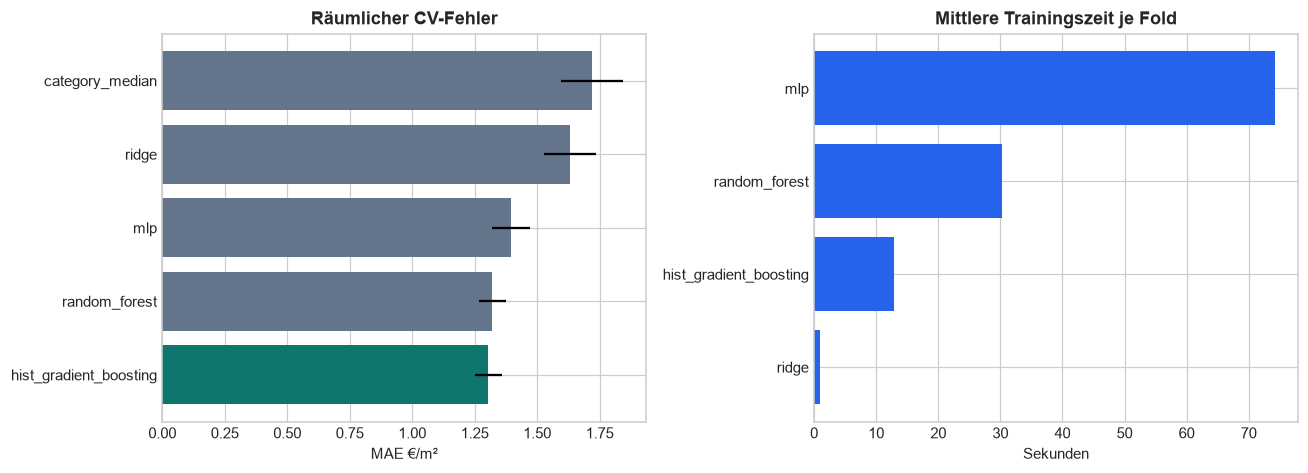

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ordered = summary.sort_values("MAE", ascending=True)
axes[0].barh(ordered["model"], ordered["MAE"], xerr=ordered["MAE_std"],
             color=[COLORS["teal"] if m == "hist_gradient_boosting" else COLORS["grey"]
                    for m in ordered["model"]])
axes[0].set(title="Räumlicher CV-Fehler", xlabel="MAE €/m²")

timed = summary.dropna(subset=["train_s"]).sort_values("train_s")
axes[1].barh(timed["model"], timed["train_s"], color=COLORS["blue"])
axes[1].set(title="Mittlere Trainingszeit je Fold", xlabel="Sekunden")
plt.tight_layout(); plt.show()

In [4]:
folds = []
for model, detail in report["models"].items():
    for fold in detail["folds"]:
        folds.append({"model": model, "fold": fold["fold"], "MAE": fold["metrics"]["mae"]})
fold_table = pd.DataFrame(folds).pivot(index="model", columns="fold", values="MAE")
fold_table["Mittel"] = fold_table.mean(axis=1)
display(fold_table.sort_values("Mittel").round(3))

baseline = summary.loc[summary["model"].eq("category_median"), "MAE"].iloc[0]
champion = summary.iloc[0]
print(f"Champion: {champion['model']} · Verbesserung zur Baseline: {(1-champion['MAE']/baseline):.1%}")

fold,1,2,3,Mittel
model,,,,
hist_gradient_boosting,1.268,1.382,1.264,1.305
random_forest,1.292,1.395,1.273,1.320
mlp,1.339,1.504,1.346,1.397
ridge,1.573,1.780,1.544,1.632
category_median,1.665,1.892,1.600,1.719


Champion: hist_gradient_boosting · Verbesserung zur Baseline: 24.1%


## Entscheidung und Übergang zu A²

Histogram Gradient Boosting gewinnt mit MAE 1,305 €/m² knapp vor Random Forest (1,320), trainiert aber etwa 2,4-mal schneller. Der Vorsprung von nur 0,016 €/m² wird **nicht** als statistisch große Überlegenheit verkauft; Random Forest bleibt Challenger.

Ridge und Kategorien-Median bleiben interpretierbare Referenzen. Das MLP belegt, dass ein neuronaler Ansatz geprüft wurde, erreichte aber sein Iterationslimit und war deutlich langsamer. Damit ist HGB der fachlich ausgewogene Kandidat für die nächste Schleife: beste räumliche CV-Güte, akzeptable Rechenzeit und erklärbar über Permutationsbeiträge.

---

**Reproduzierbarkeit:** Die visualisierten Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die jeweils genannten Skripte erzeugen diese Artefakte aus den öffentlichen Rohdaten erneut. Relative Pfade funktionieren sowohl aus der Projektwurzel als auch aus `notebooks/`.